<span style="text-align: center; color:#009999;">

# [LGBIO2050] - Medical Imaging
## *Edge detection*
</span>

### Professors :   
- Prof. G. Kerckhofs  
- Prof. J. Lee
- Prof. B. Macq
- Prof. G. Duchêne
    
### Teaching assistants : 
- Pauline Hermans (pauline.hermans@uclouvain.be)
- Nicolas Delinte (nicolas.delinte@uclouvain.be)
- Simon Francois (simon.b.francois@uclouvain.be)

**2026-2027**

<span style="color:#009999;">
 
## 1. Guidelines and Deliverables
</span>
 
- This assignment is due on **14th October 2026**.
- The jupyter notebook containing the code and **detailed answers** to the questions must be delivered in an archive (.zip folder) on Moodle, with *"Markdown cells"* containing the answers to the questions and *"Code cells"* containing the code you implemented. The answers have to be written in English.
- This work must comply with the **EPL AI Guidelines** (available on Moodle) concerning the responsible use of AI in student work. Copying code or answers from other groups or from the internet is strictly prohibited. **Any source used for inspiration must be clearly acknowledged and referenced.**
- At the end of the semester, an **individual evaluation** will allow you to demonstrate that you have a good understanding of the challenge, both in terms of the code you have written and the answers to the reflection questions. Make sure that **all group members are familiar with each challenge and understand how it works**.
- The **presentation and overall formatting of your notebook** will also be taken into account in the assessment. Make sure to **write clean, efficient, well-structured code and comment it** appropriately to make it easy to understand. Your outputs and figures should also be clear and well-presented (do not forget titles, legends, etc. where appropriate). Pay particular attention to your answers to the questions as well. **Structure your explanations clearly** and use titles, subtitles, figures, and other relevant elements to make your **answers clear and precise**.  

<span style="color:#009999;">
    
## 2. Context and objective 
</span>

 Anatomical structure segmentation on images is an important part of many medical applications. It is a process difficult to automate and it can be very time consuming if done manually. Edge detection, also called border detection, can sometimes be used in a segmentation pipeline. For this project, you will understand and implement a famous automatic edge detector called the "Canny edge detector". It is composed of the following 5 steps: 

1. Noise reduction: reduce image noise by using a simple gaussian filter to smooth the image. You can use one already implemented (the required imports are already provided). 

2. Compute image gradient intensity and direction: implement a function to compute the image gradient in both direction using Sobel operator. These images can then be combined to compute the norm and the slope direction of the gradient.

$$
|G|=\sqrt{G_{x}^{2}+G_{y}^{2}}
$$ 

$$
\theta(x,y)=arctan(\frac{G_{y}}{G_{x}})
$$

3.	Edge thinning: the next step is to reduce the borders thickness. You can use the function `thinning()` already implemented to do this step.

4.	Double thresholding: the double threshold step aims at separating borders into 2 classes, strong borders when the intensity is above the strong threshold and weak borders when the intensity is between the weak threshold and the strong threshold, the rest of the pixels can be put to a background value of 0. You can use for example as strong and weak threshold 10% and 5% of the max value of the image respectively.
 
5.	Weak borders evaluation: based on the threshold results, the last step consists of sorting the weak borders into strong borders or background. Weak borders must be transformed to strong ones if at least one of the pixels around the one being processed is a strong border. If not, a weak border joins the dark side.

The 3 following images are available to test your Canny edge detector implementation.

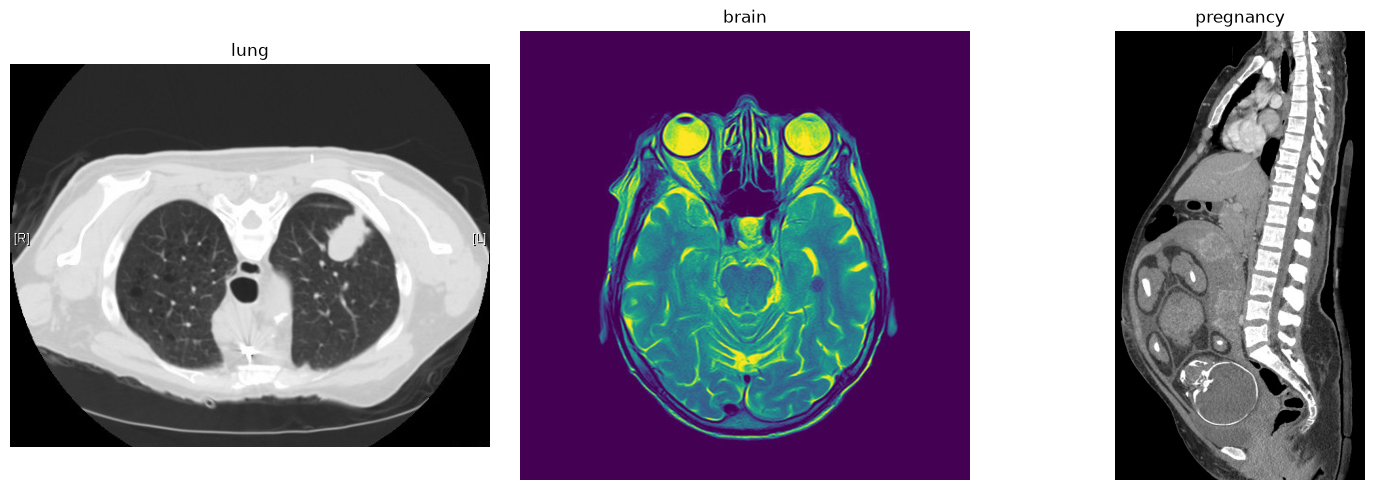

In [8]:
from skimage.io import imread
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter, convolve

img_lung = imread('imgs/CT_Lung.jpg')
img_brain = imread('imgs/MRI_Brain.jpg')
img_pregnancy = imread('imgs/CT_Pregnancy.jpg')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_lung)
axes[0].set_title("lung")
axes[0].axis("off")

axes[1].imshow(img_brain)
axes[1].set_title("brain")
axes[1].axis("off")

axes[2].imshow(img_pregnancy)
axes[2].set_title("pregnancy")
axes[2].axis("off")

plt.tight_layout()
plt.show()

<span style="color:#009999;"> 

## 3. Canny Edge Detector 
</span>

<div class="alert alert-info">

### QUESTION 1
Implement a Canny Edge Detector using the 5 steps described above. 

Show and comment briefly the result after each step of the pipeline.

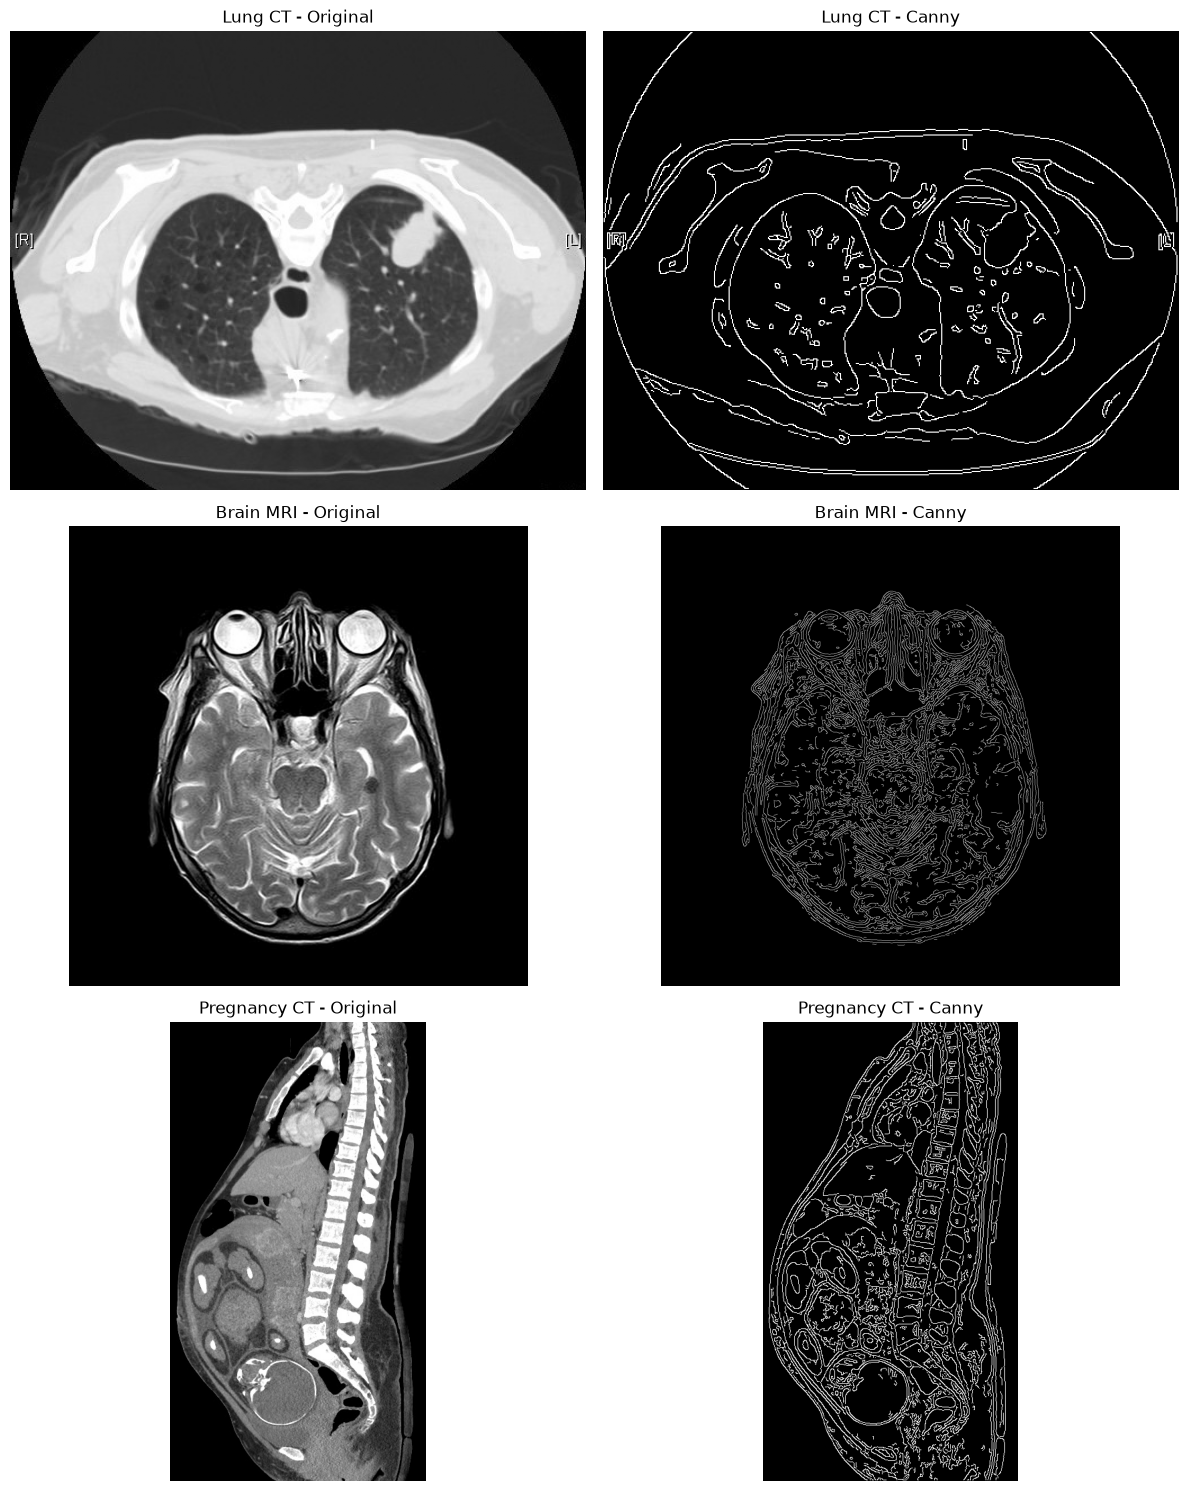

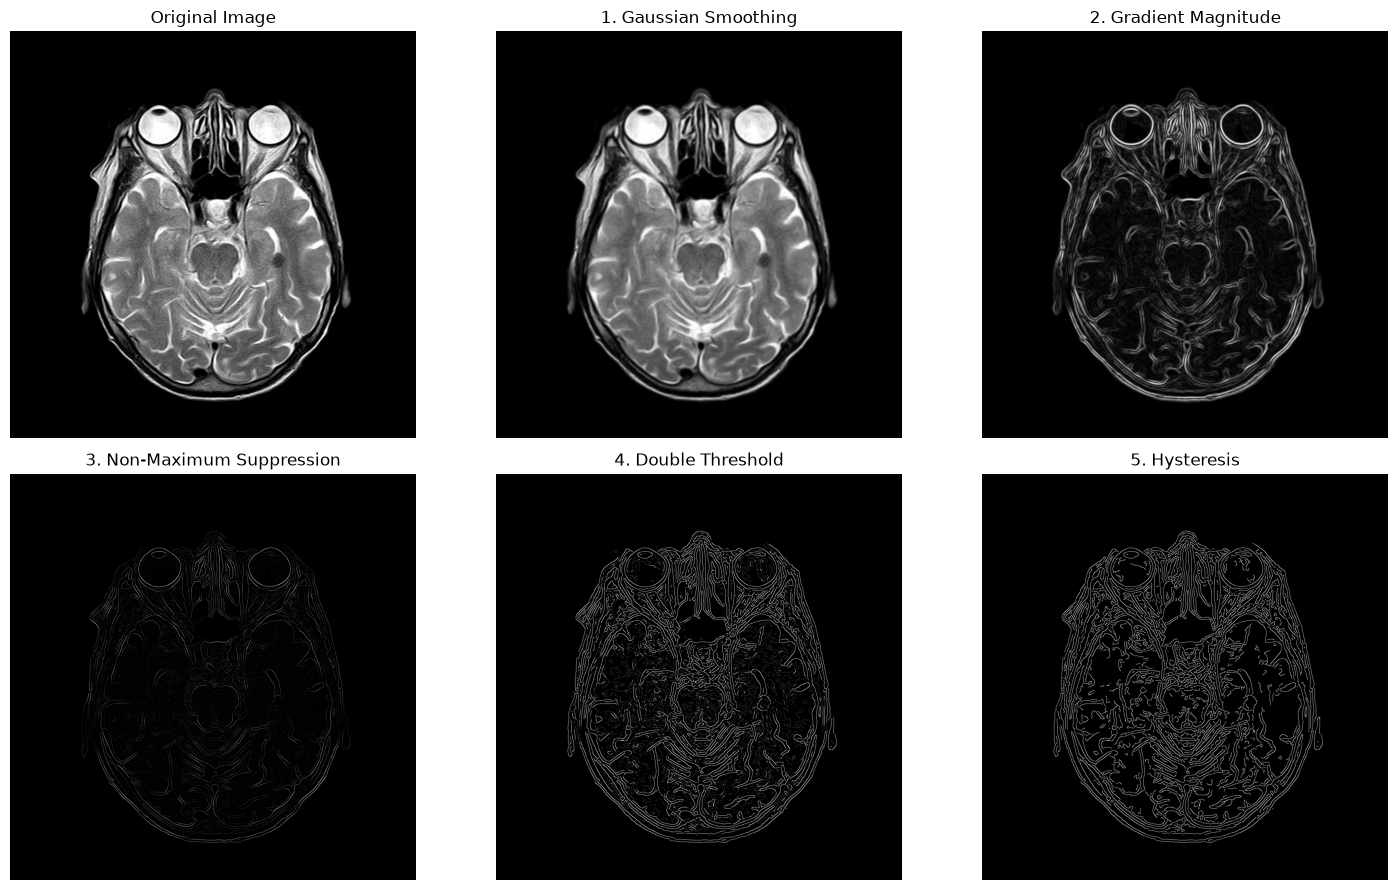

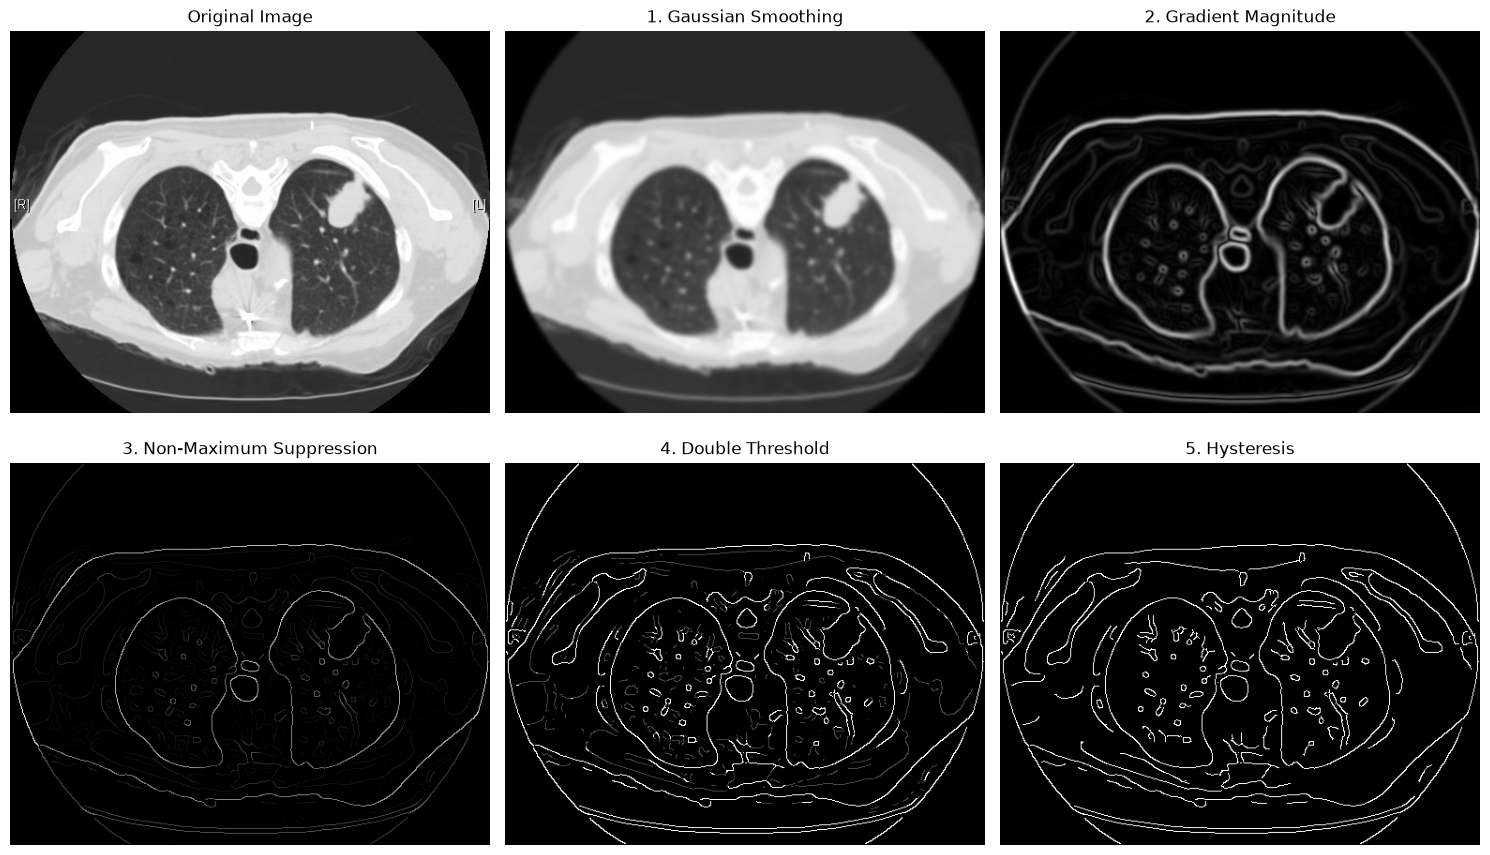

In [20]:
# è un algoritmo che individua i contorni (edge) di un'immagine
# step 1: filtro gaussiano per riduzione rumori
def gaussian_smoothing(img, sigma=2.0): #sigma controlla quando viene sfocata l'immagine
                                        # >> sigma e >> è il rumore rimosso --> possibile perdita di dettagli anatomici
    smoothed = gaussian_filter(img.astype(float), sigma=sigma)
    return smoothed
#step 2: calcolo il gradiente utilizzando due Kernel sobel che mi indicano la variazione
         # di intensità dell'immagine lungo i due assi
def sobel_gradient(img): # implemento i due sobel Kernels --> Kx e Ky
    Kx = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ])

    Ky = np.array([
        [1, 2, 1],
        [0, 0, 0],
        [-1, -2, -1]
    ])

    Gx = convolve(img, Kx) # compute gradients
    Gy = convolve(img, Ky)

    magnitude = np.sqrt(Gx**2 + Gy**2) # gradient magnitude
    angles = np.arctan2(Gy, Gx) #gradient direction (radians)
# arctan2() al contrario di arctan(Gy/Gx) gestisce correttamente anche il caso Gx = 0, evita divisioni per zero e identifica il quadrante corretto dell'angolo.
    return magnitude, angles

# step 3: codice già scritto implementa il 'non maximum suppresion' -->
# trasforma i contorni che possono essere spessi diversi pixel in contorni sottili, idealmente di 1 solo pixel
def thinning(img, angles):
    """
    Parameters
    ----------
    img : numpy.ndarray
        2D image containing the gradient magnitudes on which the edges have to be thinned.
    angles : numpy.ndarray
        2D array of the same size as img, containing the gradient angles in radians.

    Returns
    -------
    numpy.ndarray
        Thinned image.
    """
    M, N = img.shape
    Z = np.zeros((M, N), dtype=np.int32)
    angle = angles * 180. / np.pi
    angle[angle < 0] += 180

    for i in range(1, M - 1):
        for j in range(1, N - 1):

            if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                q = img[i, j + 1]
                r = img[i, j - 1]

            elif (22.5 <= angle[i, j] < 67.5):
                q = img[i - 1, j + 1]
                r = img[i + 1, j - 1]

            elif (67.5 <= angle[i, j] < 112.5):
                q = img[i - 1, j]
                r = img[i + 1, j]

            elif (112.5 <= angle[i, j] < 157.5):
                q = img[i - 1, j - 1]
                r = img[i + 1, j + 1]

            if (img[i, j] >= q) and (img[i, j] >= r): # ogni pixel viene confrontato con i 2 adiacenti lungo la direzione del gradiente
                Z[i, j] = img[i, j]                   # se il suo gradiente è maggiore degli altri 2 allora il pixel viene mantenuto
            else:
                Z[i, j] = 0                           # se il gradiente è minore di uno degli altri due viene eliminato
    return Z

#step 4: classifico i pixel in categorie
def double_threshold(img, low_ratio=0.05, high_ratio=0.10):

    high_threshold = img.max() * high_ratio
    low_threshold = img.max() * low_ratio

    strong = 255
    weak = 75

    result = np.zeros(img.shape, dtype=np.uint8)

    strong_i, strong_j = np.where(img >= high_threshold) #strong edges

    weak_i, weak_j = np.where(
        (img >= low_threshold) & (img < high_threshold) #weak edges
    )

    result[strong_i, strong_j] = strong
    result[weak_i, weak_j] = weak

    return result

#step 5: mantengo i bordi deboli solo se sono collegati a un bordo forte (direttamente o tramite altri bordi deboli)
#        permette di mantenere contorni anatomici continui anche quando alcuni tratti hanno un gradiente meno intenso
def hysteresis(img):
    strong = 255
    weak = 75
    M, N = img.shape
    result = img.copy()
    
    stack = list(zip(*np.where(result == strong))) #start from all strong pixels

    while stack:

        i, j = stack.pop()

        for di in [-1, 0, 1]:      # il codice controlla 8 pixel vicini e si propaga finchè
            for dj in [-1, 0, 1]:  # non rimangono bordi deboli collegati da esaminare

                ni = i + di
                nj = j + dj

                if 0 <= ni < M and 0 <= nj < N:

                    if result[ni, nj] == weak:
                        result[ni, nj] = strong
                        stack.append((ni, nj))

    result[result != strong] = 0 #remove remaining weak edges

    return result

#creo la funzione Canny che richiama nell'ordine corretto gli step implementati
def canny(img, sigma=1.0, low_ratio=0.05, high_ratio=0.10):

    smoothed = gaussian_smoothing(img, sigma) # STEP 1: Noise reduction 
    magnitude, angles = sobel_gradient(smoothed) # STEP 2: Gradient calculation
    thinned = thinning(magnitude, angles) # STEP 3: Non-Maximum Suppression
    thresholded = double_threshold(    # STEP 4: Double threshold
        thinned, low_ratio, high_ratio 
    )

    edges = hysteresis(thresholded) # STEP 5: Edge tracking by hysteresis

    return edges

# le immagini possono essere RGB o grayscale, inoltre devo assicurarmi siano matrici 2D
def to_grayscale(img):

    if img.ndim == 2:
        return img.astype(float)

    elif img.ndim == 3:
        rgb = img[:, :, :3].astype(float)

        gray = (
            0.299 * rgb[:, :, 0] +
            0.587 * rgb[:, :, 1] +
            0.114 * rgb[:, :, 2]
        )

        return gray

    else:
        raise ValueError("Unsupported image dimensions")
# ESEGUO IL CANNY SULLE IMMAGINI
images = [img_lung, img_brain, img_pregnancy]
titles = ["Lung CT", "Brain MRI", "Pregnancy CT"]

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

for i, img in enumerate(images):

    gray = to_grayscale(img) #convert to grayscale
    edges = canny(gray) #apply canny edge detector

    # Original image
    axes[i, 0].imshow(gray, cmap="gray")
    axes[i, 0].set_title(titles[i] + " - Original")
    axes[i, 0].axis("off")

    # Edge detection result
    axes[i, 1].imshow(edges, cmap="gray")
    axes[i, 1].set_title(titles[i] + " - Canny")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

# VISUALIZZO TUTTI GLI STEP: EX. PER IL CERVELLO IN MRI
img = to_grayscale(img_brain)

smoothed = gaussian_smoothing(img) #step 1
magnitude, angles = sobel_gradient(smoothed) #step 2
thinned = thinning(magnitude, angles) #step 3
thresholded = double_threshold(thinned) #step 4
edges = hysteresis(thresholded) #step 5

fig, axes = plt.subplots(2, 3, figsize=(15, 9)) #per visualizzare

results = [
    img,
    smoothed,
    magnitude,
    thinned,
    thresholded,
    edges
]

titles = [
    "Original Image",
    "1. Gaussian Smoothing",
    "2. Gradient Magnitude",
    "3. Non-Maximum Suppression",
    "4. Double Threshold",
    "5. Hysteresis"
]

for ax, image, title in zip(axes.flat, results, titles):

    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

# LUNG
img = to_grayscale(img_lung)

smoothed = gaussian_smoothing(img) #step 1
magnitude, angles = sobel_gradient(smoothed) #step 2
thinned = thinning(magnitude, angles) #step 3
thresholded = double_threshold(thinned) #step 4
edges = hysteresis(thresholded) #step 5

fig, axes = plt.subplots(2, 3, figsize=(15, 9)) #per visualizzare

results = [
    img,
    smoothed,
    magnitude,
    thinned,
    thresholded,
    edges
]

titles = [
    "Original Image",
    "1. Gaussian Smoothing",
    "2. Gradient Magnitude",
    "3. Non-Maximum Suppression",
    "4. Double Threshold",
    "5. Hysteresis"
]

for ax, image, title in zip(axes.flat, results, titles):

    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

<div class="alert alert-info">

### QUESTION 2
Explain how the `thinning()` function works for the step 3. 

<div class="alert alert-info">

### QUESTION 3
How does the strong and weak thresholds in step 4 influence the final detected edges ? 

<div class="alert alert-info">

### BONUS QUESTION
Show the resulting borders in color on top of the original images. 